# Customer Churn Prediction
## Goal

Predict Customer Churn

Dataset:
- Telco Customer Churn

Tech Stack:
- Python
- Pandas
- NumPy
- Matplotlib
- seaborn
- Scikit-Learn


# Import Libraries

In [288]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mtick 
from scipy.stats import chi2_contingency,mannwhitneyu

# Load Dataset

In [2]:
df=pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Initial Data Exploration

In [3]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Cleaning Data

In [5]:
clean_df=df.drop_duplicates().drop("customerID",axis=1)
clean_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [6]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
# Show unique values for columns
for c in clean_df.columns:
    print(f"{c}({clean_df[c].dtypes})--->{clean_df[c].unique()}")
    print("*************************")

gender(object)--->['Female' 'Male']
*************************
SeniorCitizen(int64)--->[0 1]
*************************
Partner(object)--->['Yes' 'No']
*************************
Dependents(object)--->['No' 'Yes']
*************************
tenure(int64)--->[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
*************************
PhoneService(object)--->['No' 'Yes']
*************************
MultipleLines(object)--->['No phone service' 'No' 'Yes']
*************************
InternetService(object)--->['DSL' 'Fiber optic' 'No']
*************************
OnlineSecurity(object)--->['No' 'Yes' 'No internet service']
*************************
OnlineBackup(object)--->['Yes' 'No' 'No internet service']
*************************
DeviceProtection(object)--->['No' 'Yes' 'No internet service']
*************************
TechSuppo

In [8]:
not_valid_values=pd.to_numeric(clean_df['TotalCharges'],errors="coerce")
clean_df[not_valid_values.isna()][['tenure','MonthlyCharges','TotalCharges','Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [9]:
clean_df[clean_df['tenure']==0][['tenure','MonthlyCharges','TotalCharges','Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


The 'TotalCharges' column contains empty strings, which prevent it from being converted to a numeric data type.

These records belong to customers with tenure = 0, indicating that they have just joined the company and have not yet been billed. Therefore, the missing TotalCharges values are expected.

### Since only a very small number of records are affected, these records were removed from the dataset.

In [10]:
clean_df['TotalCharges']=not_valid_values
clean_df=clean_df.dropna()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

# Exploratory Data Analysis (EDA)

## Target Distribution

In [11]:
churn_count=clean_df['Churn'].value_counts()
churn_percent=churn_count/len(clean_df)*100
churn_percent

Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64

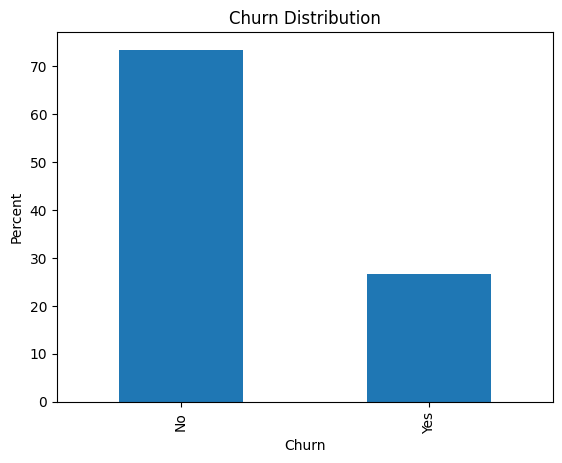

In [12]:
churn_percent.plot(kind='bar')
plt.ylabel('Percent')
plt.title('Churn Distribution')
plt.savefig('../images/churn_distribution.png')
plt.show()

The target variable is moderately imbalanced, with approximately 73% non-churn customers and 27% churn customers. While this imbalance is not severe, relying solely on accuracy may lead to misleading conclusions. Therefore,  evaluation metrics such as **F1-score and ROC-AUC** will be used to assess model performance.

## Feature Distribution

In [95]:
def plot_boxplot(feature,data=clean_df,target='Churn'):
    ax=sns.boxplot(data=data,x=feature,y=target)
    ax.set_title(f"{feature} Distribution by {target}")
    plt.show()

In [96]:
def plot_target_histogram(feature,data=clean_df,target='Churn'):
    ax=sns.histplot(data=data,x=feature,hue=target,bins=40,multiple='fill')
    ax.set_title(f"Churn Percentage by {feature}")
    ax.set_ylabel('Percentage')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    plt.show()

In [105]:
def plot_target_percentage_bar(feature,data=clean_df,target='Churn',subplot=None):
    churn_rate=pd.crosstab(data[feature],data[target],normalize='index')*100
    ax=churn_rate.plot(kind='bar',ax=subplot)
    ax.set_title(f"Churn Percentage by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 100)
    if subplot==None:
        plt.show()

### Tenure vs Churn

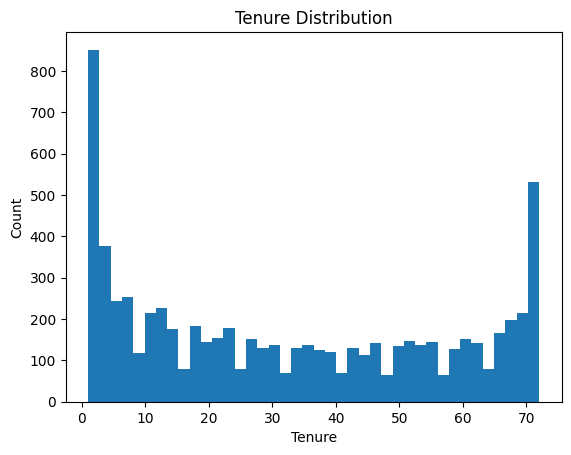

In [106]:
plt.hist(clean_df['tenure'],bins=40)
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.title('Tenure Distribution')
plt.show()

In [107]:
clean_df[['tenure']].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0


In [108]:
clean_df.groupby('Churn')['tenure'].describe().T

Churn,No,Yes
count,5163.00000,1869.000000
mean,37.65001,17.979133
std,24.07694,19.531123
min,1.00000,1.000000
25%,15.00000,2.000000
50%,38.00000,10.000000
75%,61.00000,29.000000
max,72.00000,72.000000


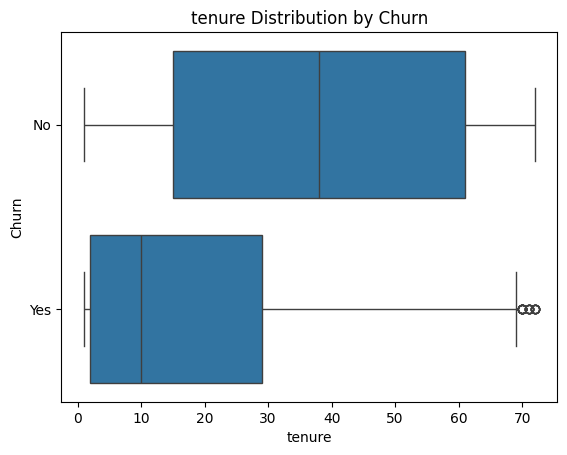

In [109]:
plot_boxplot('tenure')

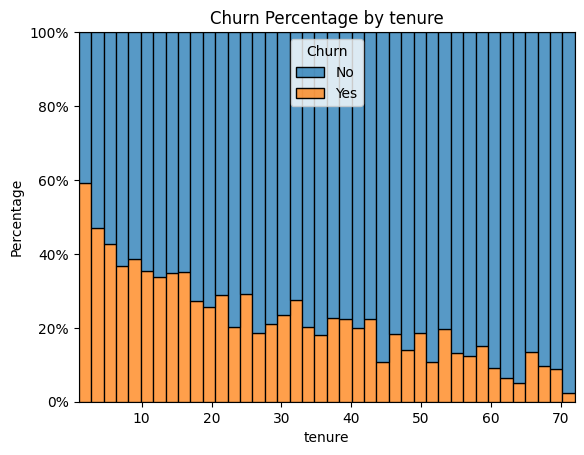

In [110]:
plot_target_histogram('tenure')

The visualizations suggest that tenure is associated with customer churn. Customers who churned  generally have much shorter tenure than those who remained . The median tenure of churned customers is considerably lower, and their values are concentrated in the early months of service.

The percentage histogram further shows that the proportion of churned customers is higher during the initial months and gradually decreases as tenure increases. Conversely, customers with longer tenure are predominantly retained, indicating that long-term customers are less likely to churn.

The observed distribution suggests a negative association between tenure and customer churn, indicating that **customers with longer service duration tend to be less likely to leave the company**.

### Contract vs Churn

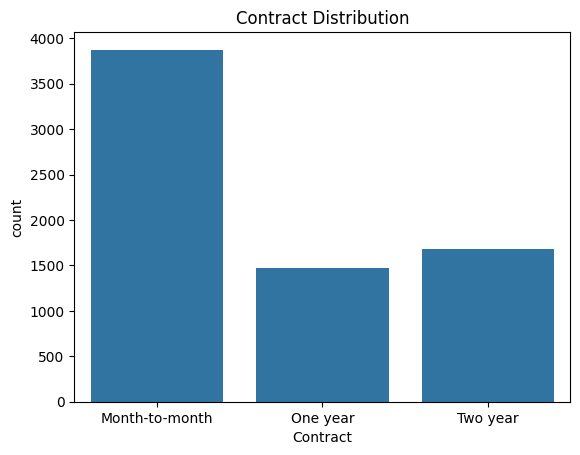

In [111]:
sns.countplot(data=clean_df,x='Contract')
plt.title('Contract Distribution')
plt.show()

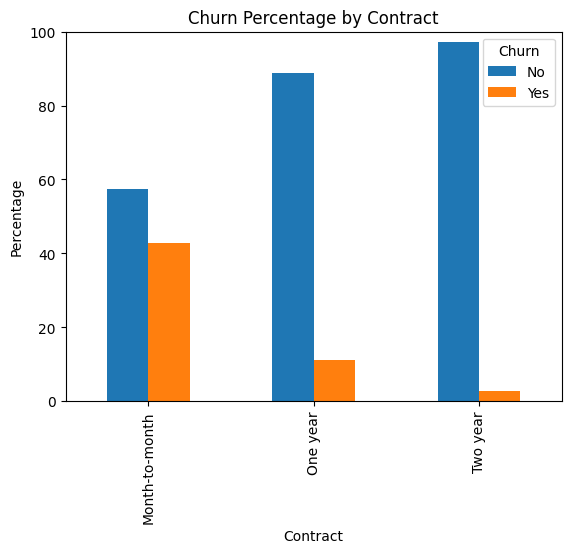

In [112]:
plot_target_percentage_bar('Contract')

Customers with month-to-month contracts have the highest churn rate. As the contract duration increases from monthly to one-year and two-year contracts, the churn rate decreases substantially. This pattern suggests that contract type is strongly associated with customer churn.

Customers with short-term contracts are more likely to leave the company. Offering incentives for customers to switch from month-to-month plans to longer-term contracts may help improve customer retention.

### InternetService vs Churn

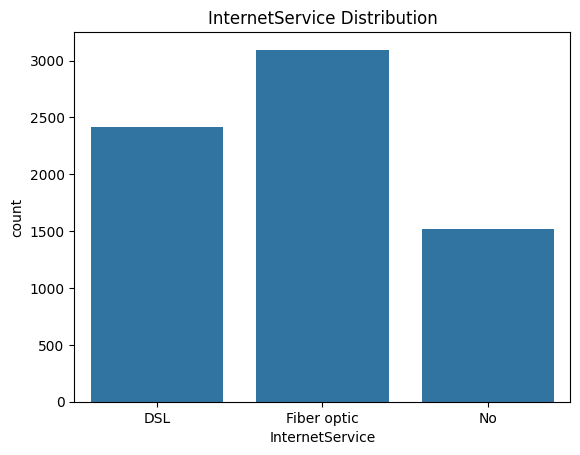

In [113]:
sns.countplot(data=clean_df,x='InternetService')
plt.title('InternetService Distribution')
plt.show()

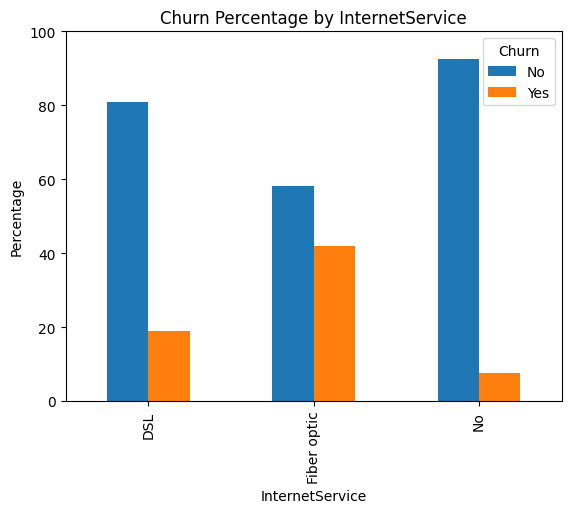

In [114]:
plot_target_percentage_bar('InternetService')

Customers using Fiber Optic internet service exhibit the highest churn rate, while customers without internet service have the lowest. DSL customers fall between these two groups. The noticeable differences in churn rates across service types suggest that InternetService may be an important factor associated with customer churn.

### MonthlyCharges vs Churn

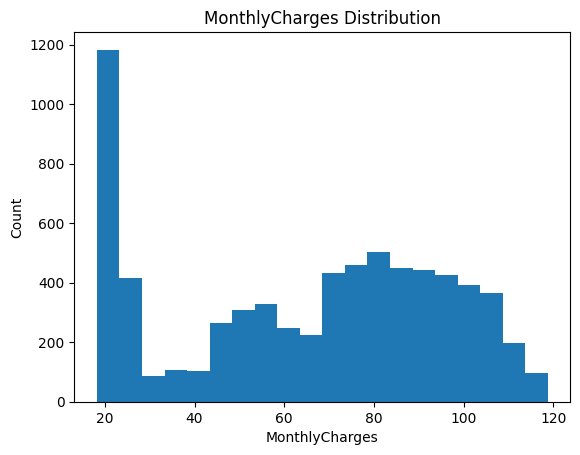

In [115]:
plt.hist(clean_df['MonthlyCharges'],bins=20)
plt.xlabel('MonthlyCharges')
plt.ylabel('Count')
plt.title('MonthlyCharges Distribution')
plt.show()

In [116]:
clean_df.groupby('Churn')['MonthlyCharges'].describe().T

Churn,No,Yes
count,5163.000000,1869.000000
mean,61.307408,74.441332
std,31.094557,24.666053
min,18.250000,18.850000
25%,25.100000,56.150000
50%,64.450000,79.650000
75%,88.475000,94.200000
max,118.750000,118.350000


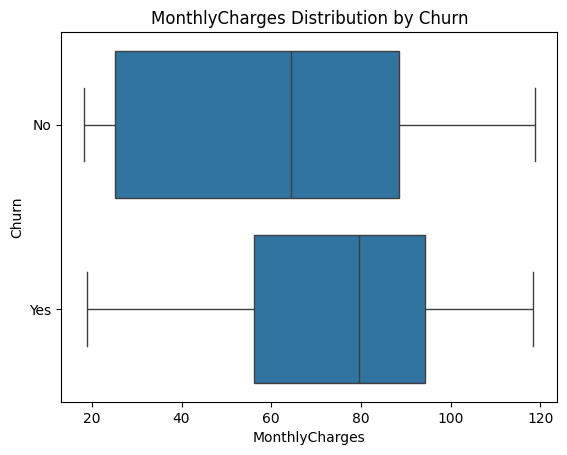

In [117]:
plot_boxplot('MonthlyCharges')

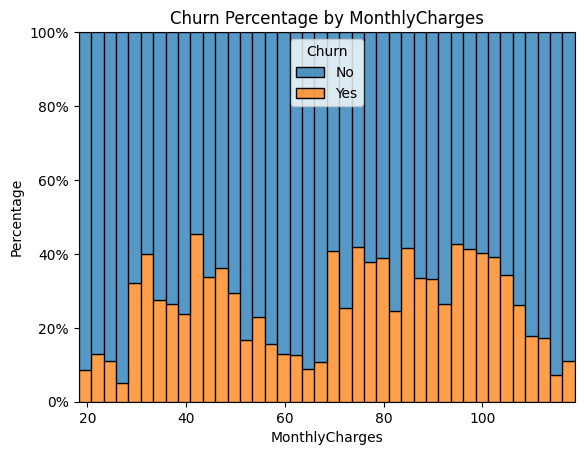

In [118]:
plot_target_histogram('MonthlyCharges')

MonthlyCharges appears to have a weaker association with customer churn compared to features such as tenure and Contract. Although churned customers tend to have slightly higher monthly charges, the substantial overlap between the two groups suggests that MonthlyCharges alone is not a strong discriminator of churn.

### TotalCharges vs Churn

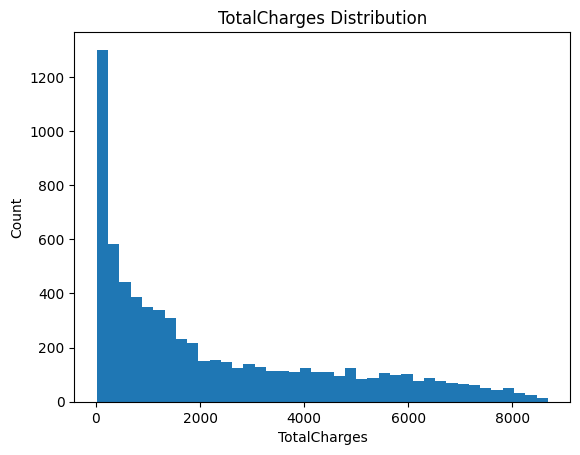

In [119]:
plt.hist(clean_df['TotalCharges'],bins=40)
plt.xlabel('TotalCharges')
plt.ylabel('Count')
plt.title('TotalCharges Distribution')
plt.show()

In [120]:
clean_df.groupby('Churn')['TotalCharges'].describe().T

Churn,No,Yes
count,5163.000000,1869.000000
mean,2555.344141,1531.796094
std,2329.456984,1890.822994
min,18.800000,18.850000
25%,577.825000,134.500000
50%,1683.600000,703.550000
75%,4264.125000,2331.300000
max,8672.450000,8684.800000


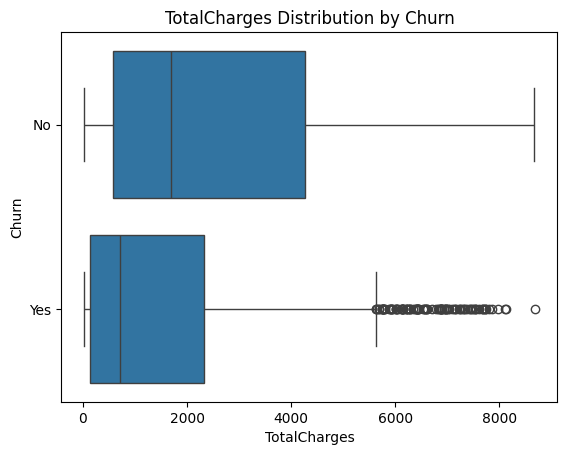

In [121]:
plot_boxplot('TotalCharges')

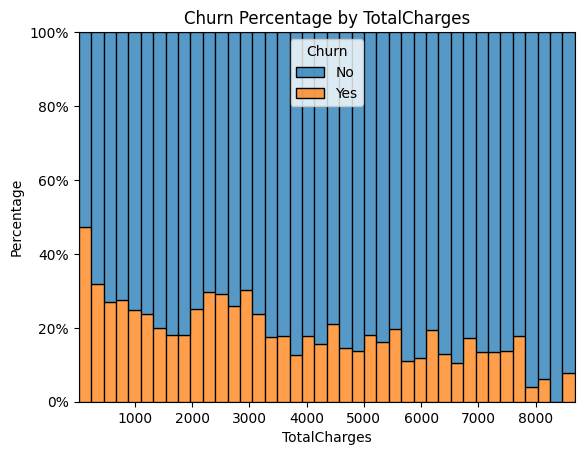

In [122]:
plot_target_histogram('TotalCharges')

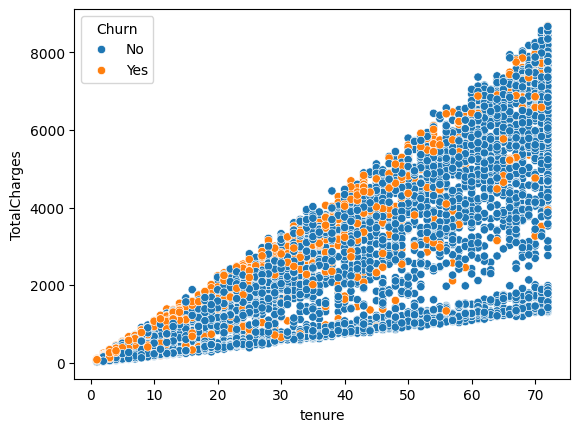

In [123]:
sns.scatterplot(data=clean_df,x='tenure',y='TotalCharges',hue='Churn')
plt.show()

The boxplot and histogram suggest a negative association between TotalCharges and customer churn. Customers with higher cumulative charges tend to have lower churn rates, although the separation between churned and retained customers is less pronounced than that observed for tenure. The scatter plot also reveals a strong positive association between TotalCharges and tenure, indicating that these two features share overlapping information. However, whether TotalCharges provides additional predictive value beyond tenure should be determined during the modeling stage.

### Payment Method vs Churn

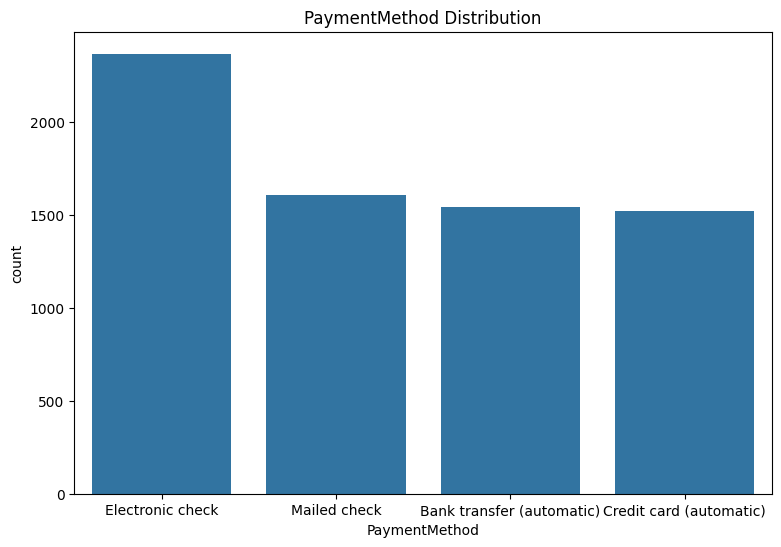

In [124]:
plt.figure(figsize=(9,6))
sns.countplot(data=clean_df,x='PaymentMethod')
plt.title('PaymentMethod Distribution')
plt.show()

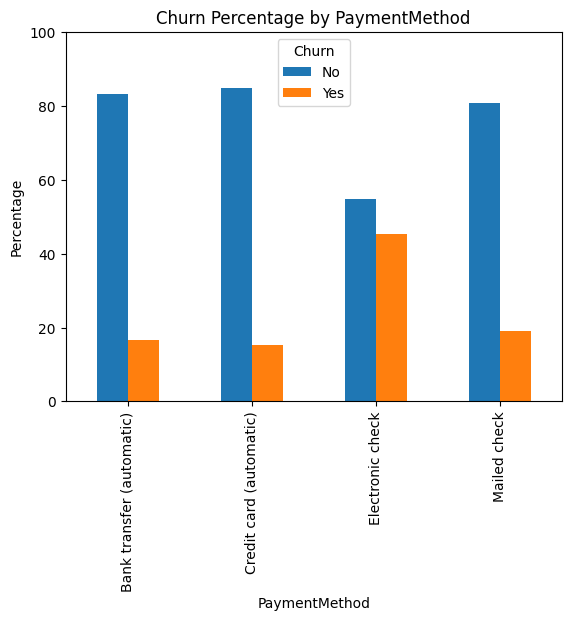

In [125]:
plot_target_percentage_bar('PaymentMethod')

Customers using Electronic Check have a noticeably higher churn rate than customers using the other payment methods, whose churn rates are relatively similar. This suggests that the payment method may be associated with customer churn, although further analysis is required to determine whether this pattern is influenced by other customer characteristics.

### Gender vs Churn

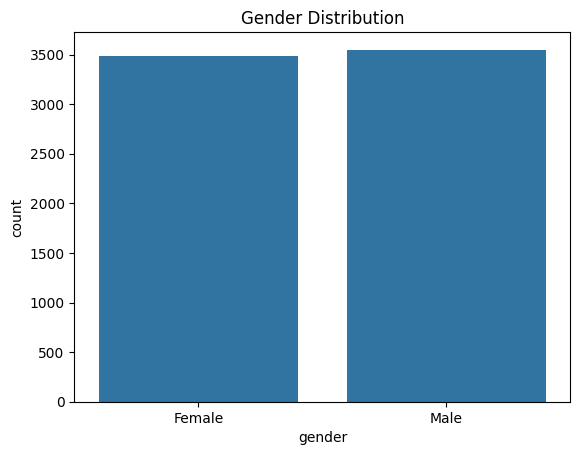

In [81]:
sns.countplot(data=clean_df,x='gender')
plt.title('Gender Distribution')
plt.show()

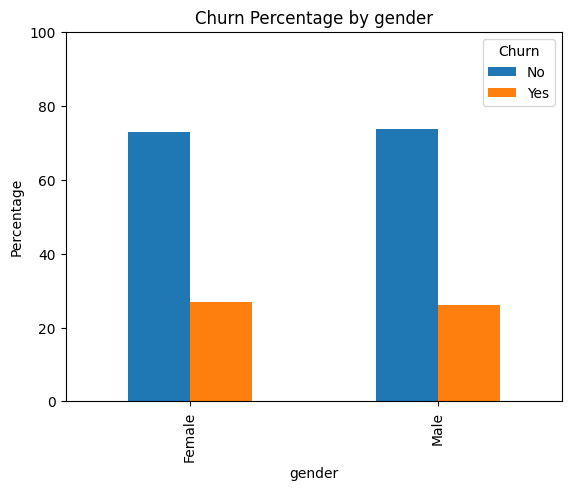

In [32]:
plot_target_percentage_bar('gender')

The churn rates for male and female customers are nearly identical. Based on the observed distribution, gender does not appear to be strongly associated with customer churn.

### Remaining Features

In [33]:
other_columns=['PhoneService', 'MultipleLines','SeniorCitizen', 'Partner', 'Dependents', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies', 'PaperlessBilling']

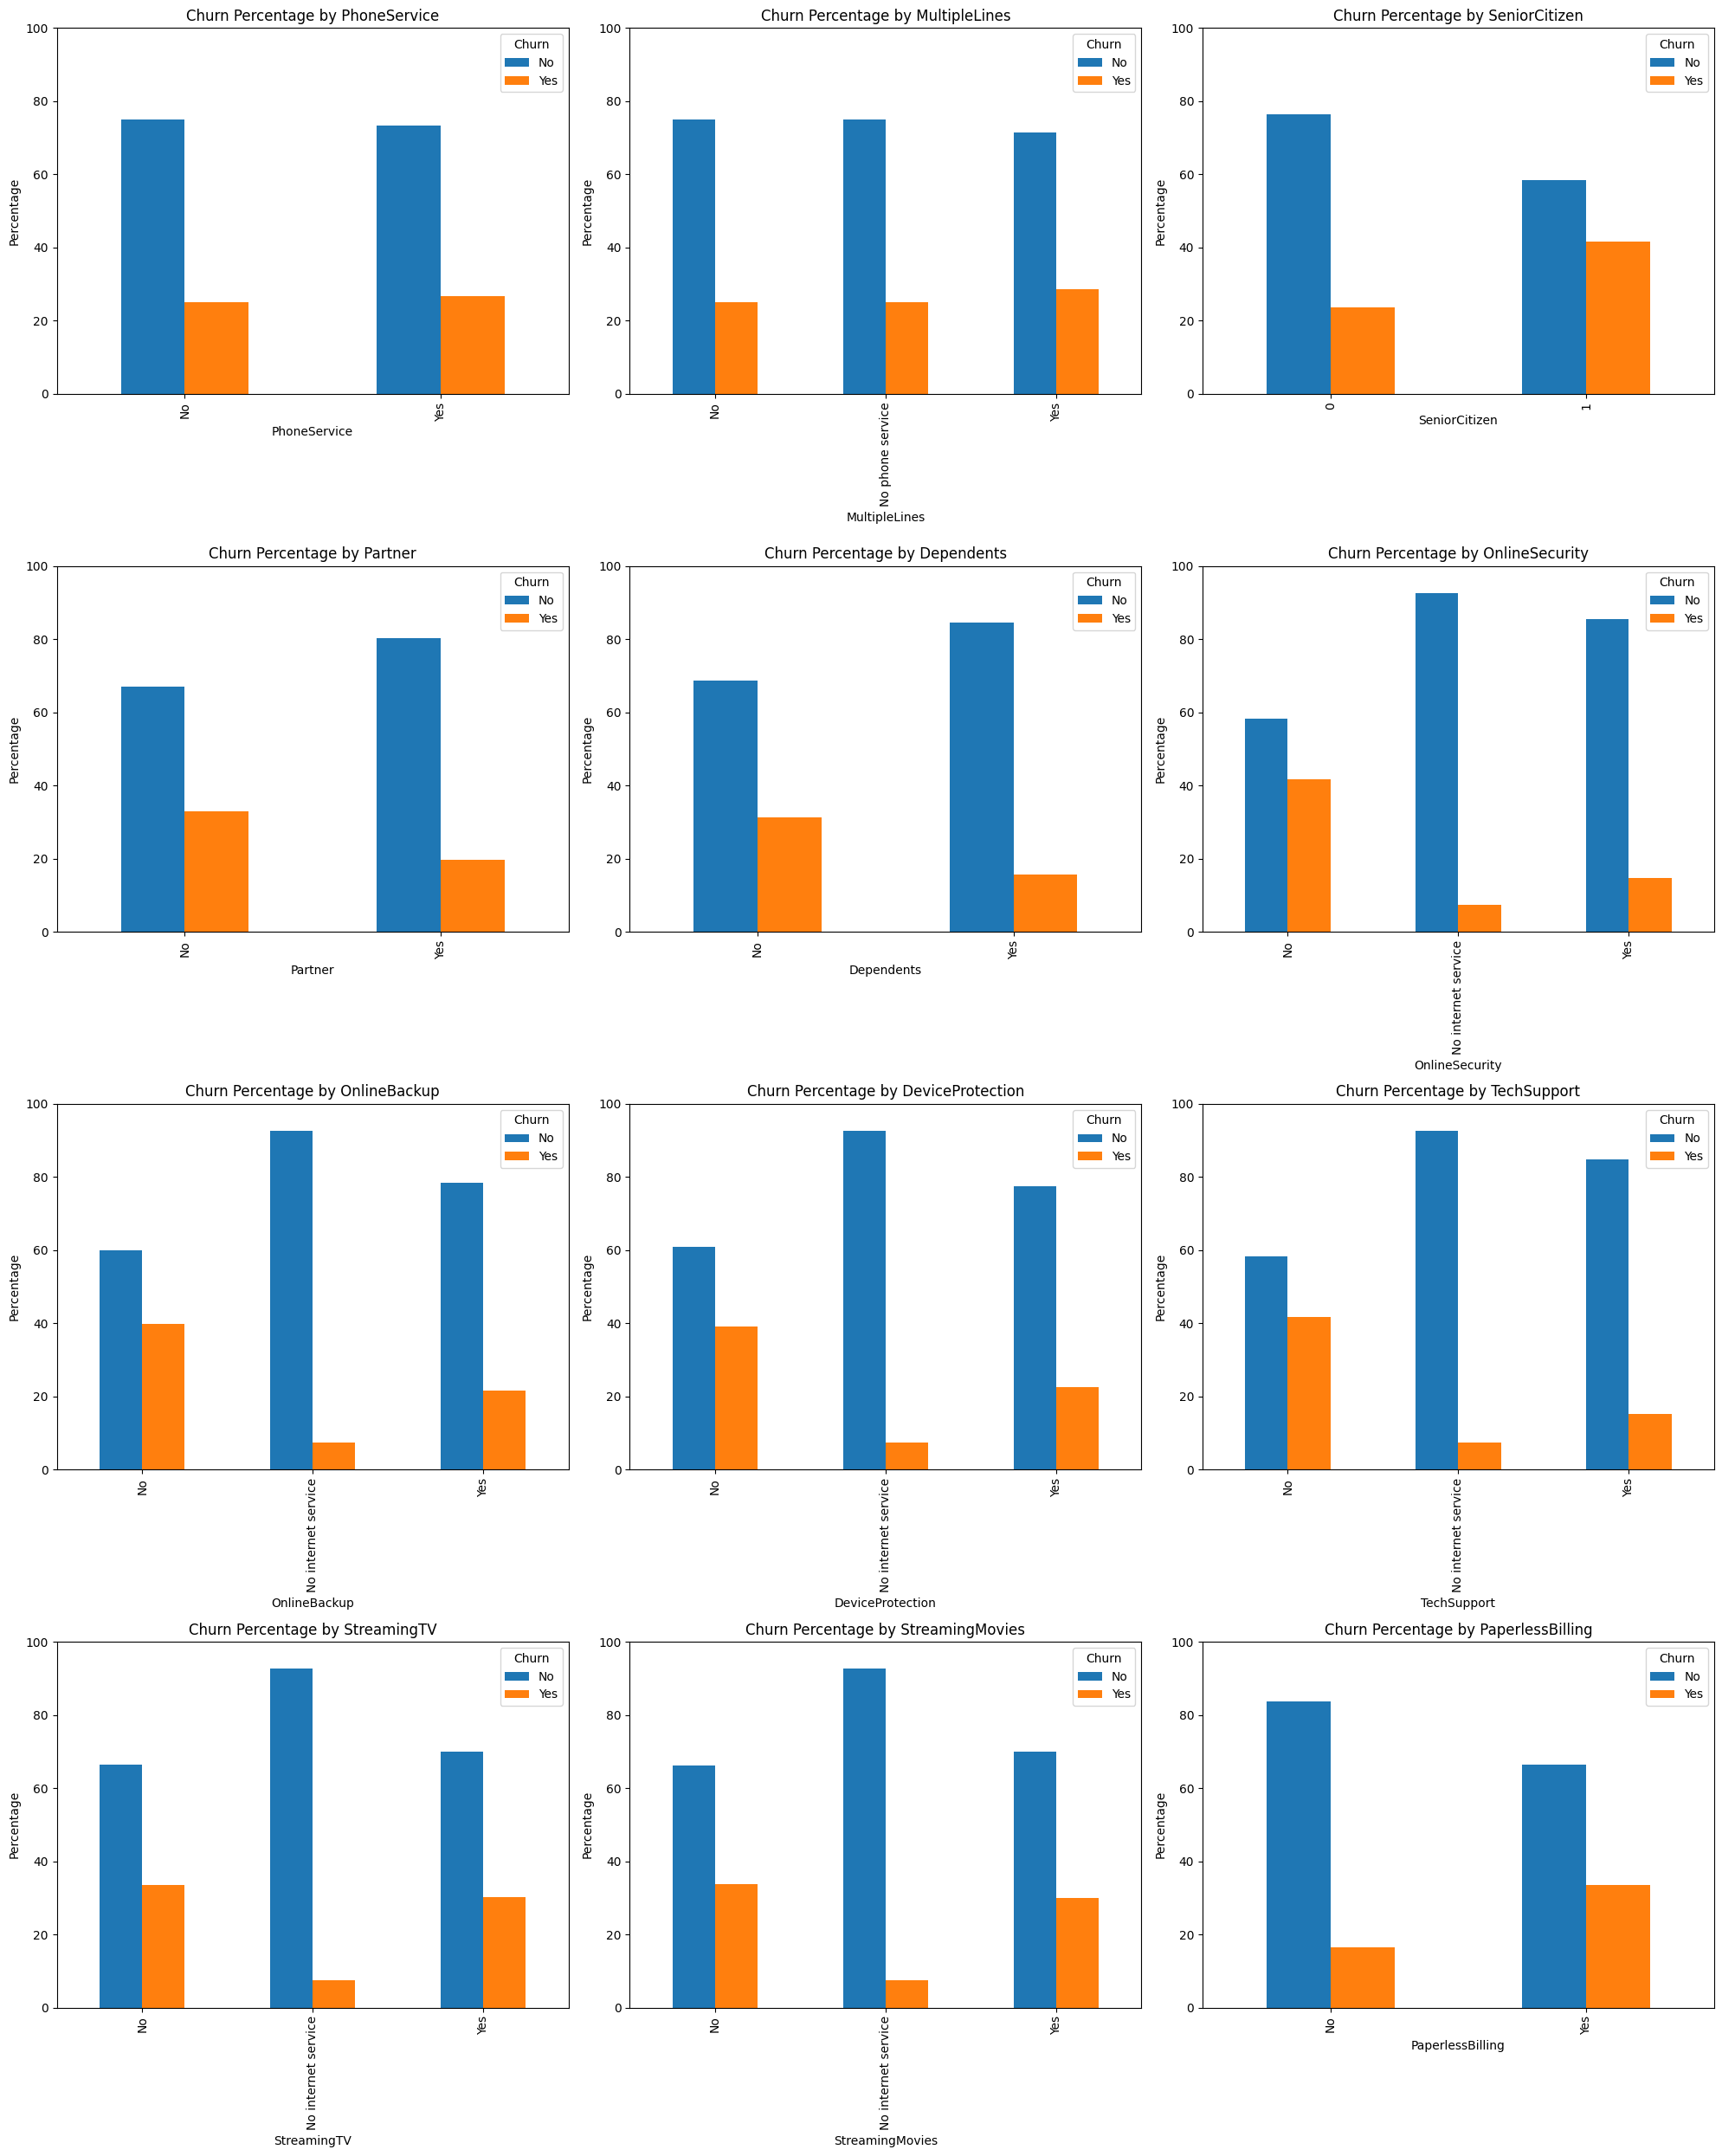

In [34]:
figure,subplot=plt.subplots(4,3,figsize=(20,25))
subplot=subplot.flatten()
i=0
for feature in other_columns:
    plot_target_percentage_bar(feature,subplot=subplot[i])
    i+=1
plt.tight_layout()
plt.show()

The remaining categorical features were explored using percentage bar charts to identify potential associations with customer churn. Features such as OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection, Partner, and Dependents exhibit noticeable differences in churn rates across categories, suggesting that they may provide useful predictive information. In contrast, PhoneService, MultipleLines, StreamingTV, and StreamingMovies show relatively small differences between groups, indicating weaker associations with churn. Additionally, PaperlessBilling and SeniorCitizen display moderate differences that may also contribute to prediction performance. These observations are based on exploratory analysis and will be further validated during the modeling stage.

## Multivariate Analysis

### Correlation Between Numerical Features

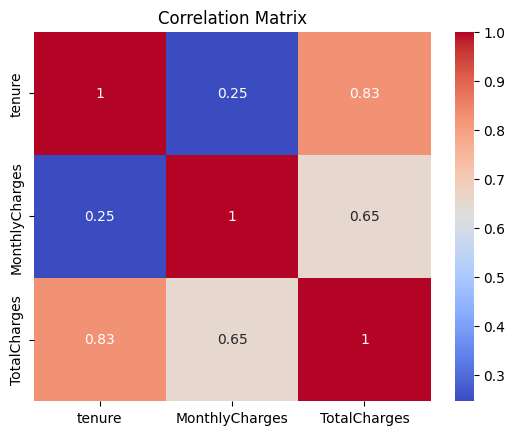

In [299]:
numerical_features=['tenure','MonthlyCharges','TotalCharges']
corr=clean_df[numerical_features].corr(method='pearson')
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix reveals a strong positive correlation between tenure and TotalCharges, which is expected because customers with longer service duration generally accumulate higher total charges over time. In comparison, MonthlyCharges shows only a weak correlation with tenure and a moderate correlation with TotalCharges.

Although tenure and TotalCharges contain overlapping information, they should not be considered redundant based solely on their high correlation. Previous exploratory analysis showed that customers with similar tenure may have substantially different TotalCharges, indicating that TotalCharges may provide additional predictive information beyond service duration. Therefore, the final decision regarding feature selection will be made during the modeling stage based on model performance and feature importance.

### Categorical Features 

In [148]:
def plot_crosstab_heatmap(feature1,feature2,data=clean_df,sublopt=None):
    table = pd.crosstab(data[feature1],data[feature2],normalize="index")*100
    ax=sns.heatmap(table,annot=True,fmt=".1f",cmap="Blues",ax=sublopt)
    ax.set_title(f"{feature1} vs {feature2}")
    if sublopt==None:
        plt.show()

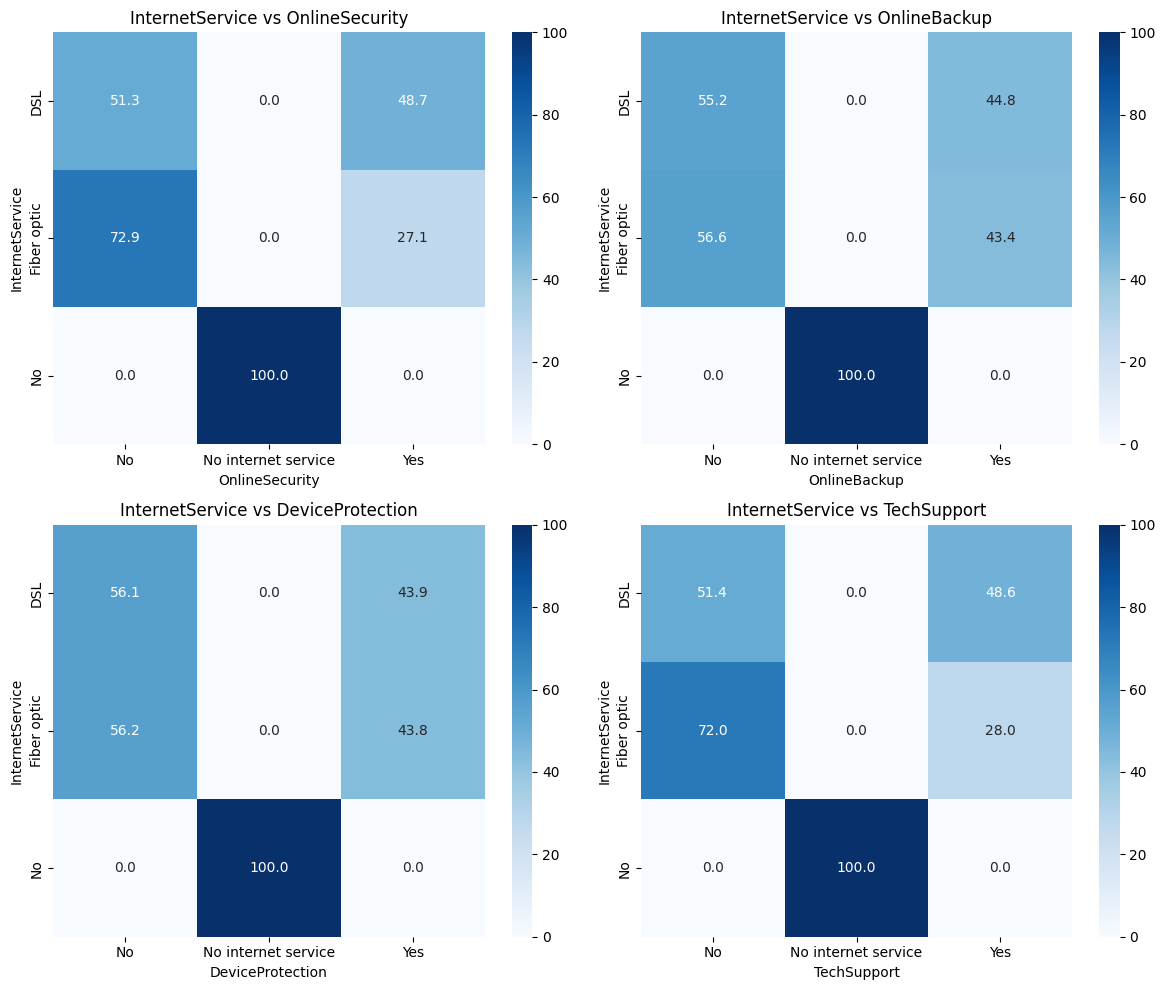

In [141]:
features=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']
figure,subplot=plt.subplots(2,2,figsize=(12,10))
subplot=subplot.flatten()
i=0
for feature2 in features:
    plot_crosstab_heatmap('InternetService',feature2,sublopt=subplot[i])
    i+=1
plt.tight_layout()
plt.show()

The cross-tabulation heatmaps reveal a strong dependency between InternetService and the service-related features OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport. Customers without an internet service are almost exclusively assigned to the "No internet service" category for these features, which is consistent with the business logic since these services require an active internet connection.

For customers with DSL or Fiber Optic services, the distribution is divided between the "Yes" and "No" categories, indicating that these services are optional rather than automatically included.

Although these features are associated with InternetService, they represent different business concepts and may still provide complementary predictive information. Their contribution will be evaluated during the modeling stage.

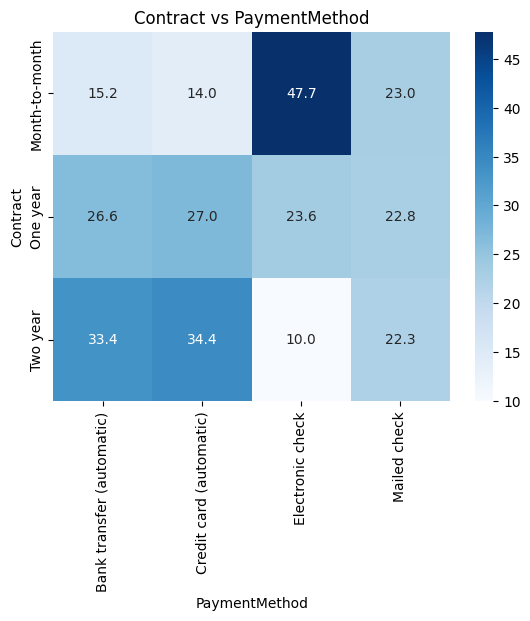

In [149]:
plot_crosstab_heatmap('Contract','PaymentMethod')

The heatmap indicates a noticeable association between Contract and PaymentMethod. Customers with month-to-month contracts are considerably more likely to use Electronic check, whereas customers with longer-term contracts more frequently use automatic payment methods, such as bank transfers and credit cards.

This observation is consistent with previous EDA findings, where both month-to-month contracts and Electronic check were associated with higher churn rates. The overlap suggests that these features share some common information; however, they describe different aspects of customer behavior and should not be considered redundant based solely on this dependency. Their individual contributions will be further evaluated during the modeling stage.

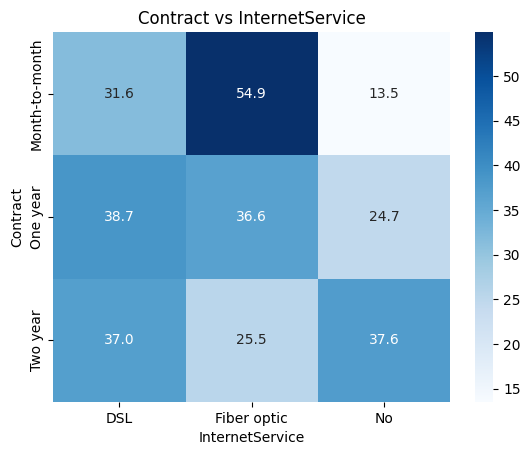

In [143]:
plot_crosstab_heatmap('Contract','InternetService')

The heatmap suggests an association between Contract and InternetService. Customers with month-to-month contracts appear more likely to subscribe to Fiber optic services, whereas customers with longer-term contracts are relatively more represented among DSL and No internet service users. This pattern indicates that the distribution of internet service types varies across contract categories.

Although these features are associated, they describe different aspects of customer behavior. Contract reflects the customer's commitment period, while InternetService represents the type of service subscribed to. Therefore, both features may provide complementary predictive information during model development.

## Statistical Tests

### Categorical Features 

In [266]:
def chi_square_test(feature,target='Churn',data=clean_df,alpha=0.05):
    contingency_table=pd.crosstab(data[feature],data[target])
    stat,p_value,df,expected= chi2_contingency(contingency_table,correction=False)
    v=cramers_v(contingency_table,stat)
    return {'Feature':feature,'Chi Square Statistic':stat,'p-value':p_value,"Cramer's V":v,'significant association':p_value<alpha}

In [267]:
def cramers_v (table,chi2_stat):
    n=table.values.sum()
    phi2=chi2_stat/n
    v=np.sqrt(phi2/(min(table.shape)-1))
    return v

Cramér's V was implemented manually to reinforce the understanding of the underlying statistical measure. 

Library:from scipy.stats.contingency import association

In [268]:
categorical_features=['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
                      'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
                      'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

In [302]:
categorical_results = [chi_square_test(feature) for feature in categorical_features]
chi2_results = pd.DataFrame(categorical_results)

In [303]:
chi2_results=chi2_results.sort_values("Cramer's V",ascending=False).reset_index(drop=True)

In [304]:
chi2_results

,Feature,Chi Square Statistic,p-value,Cramer's V,significant association
0,Contract,1179.545829,7.326182e-257,0.409560,True
1,OnlineSecurity,846.677389,1.400687e-184,0.346992,True
2,TechSupport,824.925564,7.407808e-180,0.342506,True
3,InternetService,728.695614,5.831199e-159,0.321909,True
4,PaymentMethod,645.429900,1.426310e-139,0.302960,True
5,OnlineBackup,599.175185,7.776099e-131,0.291902,True
6,DeviceProtection,555.880327,1.959389e-121,0.281159,True
7,StreamingMovies,374.268432,5.353560e-82,0.230702,True
8,StreamingTV,372.456502,1.324641e-81,0.230143,True
9,PaperlessBilling,257.756252,5.291852e-58,0.191454,True


To validate the findings obtained during EDA, statistical tests are performed. For categorical features, the Chi-Square Test of Independence is used to evaluate whether a feature is associated with the target variable (Churn). In addition, Cramér's V is reported to measure the strength of the association, providing information beyond statistical significance.


For each categorical feature, the following hypotheses are tested:

- Null Hypothesis (H₀): The feature and customer churn are independent (no association exists).
- Alternative Hypothesis (H₁): The feature and customer churn are associated.

A significance level of α = 0.05 is used throughout this analysis. If the p-value is less than α, the null hypothesis is rejected, indicating evidence of an association between the feature and customer churn.

Although the Chi-Square test indicates whether an association is statistically significant, it does not quantify the strength of that relationship. Therefore, Cramér's V is calculated as an effect size measure for every categorical feature.


Consequently, the statistical analysis in this section considers both the p-value (statistical significance) and Cramér's V (effect size), allowing us to evaluate not only whether a relationship exists but also how strong that relationship is.

### Numerical Features

In [337]:
def mann_whitney_u_test(feature,target='Churn',data=clean_df,alpha=0.05):
    churn=data[data[target]=='Yes'][feature]
    non_churn=data[data[target]=='No'][feature]
    churn_stat,p_value= mannwhitneyu(non_churn,churn,alternative='two-sided')
    r=rank_biserial_corr(churn_stat,len(churn),len(non_churn))
    return {'Feature':feature,'U Statistic(Churn Group)':churn_stat,'p-value':p_value,"Rank Biserial Correlation":r,'significant association':p_value<alpha}

In [338]:
def rank_biserial_corr(u_stat,n1,n2):
    rbc=1-(2*u_stat/(n1*n2))
    return rbc

In [339]:
numerical_results=[mann_whitney_u_test(feature) for feature in numerical_features]
mann_whitney_u_results = pd.DataFrame(numerical_results)

In [340]:
mann_whitney_u_results

,Feature,U Statistic(Churn Group),p-value,Rank Biserial Correlation,significant association
0,tenure,7154668.0,6.043047e-211,-0.482887,True
1,MonthlyCharges,3663498.5,8.467195e-54,0.240698,True
2,TotalCharges,6288982.0,1.995985e-84,-0.303464,True


To statistically validate the findings obtained during the exploratory data analysis (EDA), the Mann–Whitney U test was applied to all numerical features. This non-parametric test evaluates whether the distributions of a numerical feature differ significantly between churned and non-churned customers without assuming normality.

In addition to statistical significance, the Rank-Biserial Correlation (RBC) was calculated as an effect size measure. While the p-value indicates whether a statistically significant difference exists, the Rank-Biserial Correlation quantifies the magnitude and direction of that difference.

For each numerical feature, the following hypotheses were tested:

- Null Hypothesis (H₀): The distribution of the feature is the same for churned and non-churned customers.
- Alternative Hypothesis (H₁): The distribution of the feature differs between churned and non-churned customers.

A significance level of α = 0.05 was used throughout the analysis.

The Rank-Biserial Correlation ranges from −1 to +1.

- Positive values indicate that the feature tends to have higher values among churned customers.
- Negative values indicate that the feature tends to have higher values among retained (non-churned) customers.
- Values closer to 0 indicate weaker differences, whereas values closer to ±1 indicate stronger separation between the two groups.

The statistical analysis confirms the observations made during the exploratory data analysis. All numerical features exhibit statistically significant differences between churned and retained customers. Among them, tenure demonstrates the strongest discriminatory power, followed by TotalCharges, whereas MonthlyCharges shows a weaker but still meaningful association with customer churn.